In [31]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

# load
with open('aggregated_data.json','r',encoding='utf-8') as f:
    data = json.load(f)

# helper
def strip_utm(url):
    return re.sub(r"[?&]utm_source=chatgpt\.com", "", url)

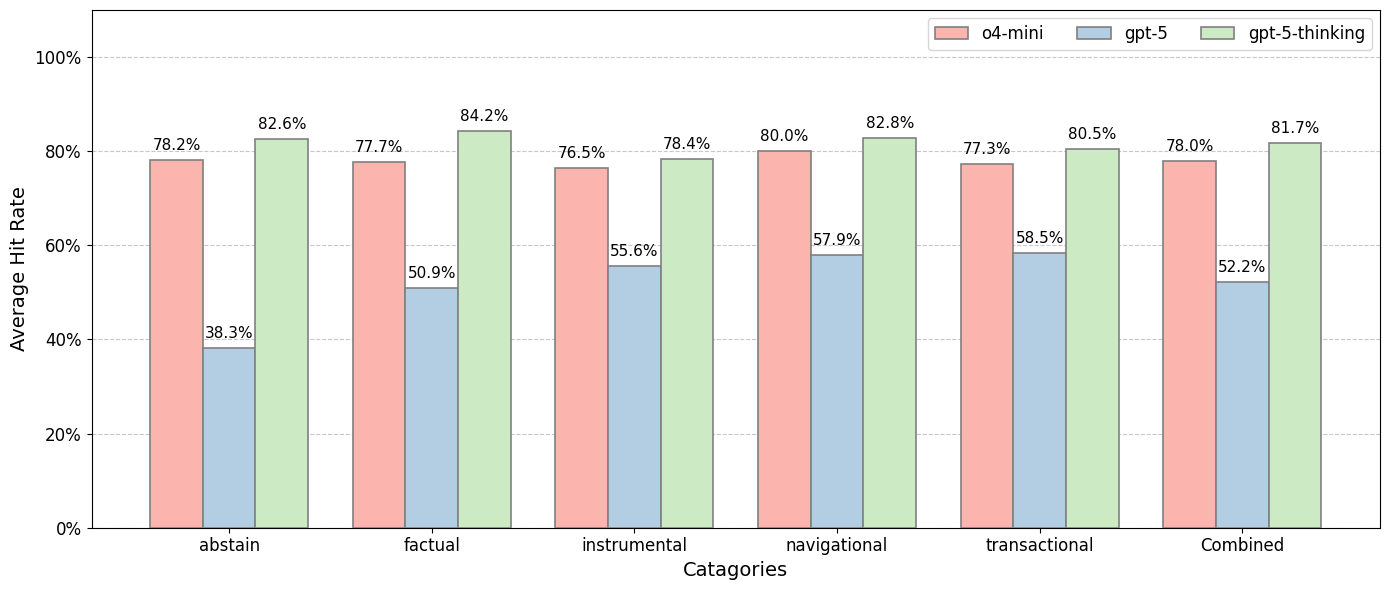

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# --- COMMON FUNCTION TO CALCULATE AVG HIT RATE ---
def compute_avg_hr(data, include_gpt5="o4-mini"):
    # filter only google+bing overlap
    for cat in list(data.keys()):
        data[cat] = {hid: rec for hid, rec in data[cat].items() if rec['google_urls']}
    for cat in list(data.keys()):
        data[cat] = {hid: rec for hid, rec in data[cat].items() if rec['bing_urls']}
    
    # keep categories depending on flag
    if include_gpt5=="gpt-5":
        filtered = {cat: har_dict for cat, har_dict in data.items() if "_gpt-5" in cat}
    elif include_gpt5=="gpt-5-thinking":
        filtered = {cat: har_dict for cat, har_dict in data.items() if "_gpt-5-think" in cat}
    else:
        filtered = {cat: har_dict for cat, har_dict in data.items() if "_gpt-5" not in cat}
    
    records = []
    for cat, har_dict in filtered.items():
        for har_id, rec in har_dict.items():
            prompts = rec['urls_from_prompt']
            search_urls = [e['url'] for e in rec['bing_urls'] + rec['google_urls']]
            total = len(prompts)
            hits = sum(1 for p in prompts if any(s == p or s in p for s in search_urls))
            records.append({
                'category': cat.replace("_gpt-5", "").replace("-thinking", ""),
                'hit_rate': hits / total if total else 0
            })
    df = pd.DataFrame(records)
    return df.groupby('category')['hit_rate'].mean().sort_index()

# --- CALCULATE THREE SERIES ---
avg_hr_o4     = compute_avg_hr(data.copy(), include_gpt5="o4-mini")         # default path
avg_hr_gpt5   = compute_avg_hr(data.copy(), include_gpt5="gpt-5")
avg_hr_gpt5tk = compute_avg_hr(data.copy(), include_gpt5="gpt-5-thinking")

# --- ALIGN INDEXES (per-category) ---
all_cats = sorted(set(avg_hr_o4.index) | set(avg_hr_gpt5.index) | set(avg_hr_gpt5tk.index))
avg_hr_o4     = avg_hr_o4.reindex(all_cats, fill_value=0)
avg_hr_gpt5   = avg_hr_gpt5.reindex(all_cats, fill_value=0)
avg_hr_gpt5tk = avg_hr_gpt5tk.reindex(all_cats, fill_value=0)

# --- ADD "combined" CATEGORY (mean across categories) ---
combined_label = "Combined"
avg_hr_o4     = pd.concat([avg_hr_o4,     pd.Series({combined_label: avg_hr_o4.mean()})])
avg_hr_gpt5   = pd.concat([avg_hr_gpt5,   pd.Series({combined_label: avg_hr_gpt5.mean()})])
avg_hr_gpt5tk = pd.concat([avg_hr_gpt5tk, pd.Series({combined_label: avg_hr_gpt5tk.mean()})])

# ensure identical order for all three & place "combined" at the end
ordered_cats = all_cats + [combined_label]
avg_hr_o4     = avg_hr_o4.reindex(ordered_cats)
avg_hr_gpt5   = avg_hr_gpt5.reindex(ordered_cats)
avg_hr_gpt5tk = avg_hr_gpt5tk.reindex(ordered_cats)

# --- PLOT ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(ordered_cats))
width = 0.26  # narrower to fit 3 bars nicely

pastel = plt.get_cmap('Pastel1')
bars1 = ax.bar(x - width,  avg_hr_o4.values,     width,
               label='o4-mini',
               edgecolor='gray', linewidth=1.2, color=pastel(0), zorder=3)
bars2 = ax.bar(x,           avg_hr_gpt5.values,   width,
               label='gpt-5',
               edgecolor='gray', linewidth=1.2, color=pastel(1), zorder=3)
bars3 = ax.bar(x + width,  avg_hr_gpt5tk.values, width,
               label='gpt-5-thinking',
               edgecolor='gray', linewidth=1.2, color=pastel(2), zorder=3)

# y-axis formatting
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# labels & title
ax.set_ylabel('Average Hit Rate', fontsize=14)
ax.set_xlabel('Catagories', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(
    ["instrumental" if lbl == "instramental" else lbl for lbl in ordered_cats],
    fontsize=12
)
ax.tick_params(axis='y', labelsize=12)

# subtle gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# annotate bars
def annotate(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1%}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=11)

annotate(bars1)
annotate(bars2)
annotate(bars3)

ax.legend(fontsize=12, ncols=3)  # compact legend
plt.tight_layout()
plt.savefig("plots/avg_combined_hit_rate.svg", format="svg")
plt.show()


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# --- COMMON FUNCTION TO CALCULATE AVG HIT RATES ---
def compute_avg_hr(data, include_gpt5="o4-mini"):
    # filter only google+bing overlap
    for cat in list(data.keys()):
        data[cat] = {hid: rec for hid, rec in data[cat].items() if rec['google_urls']}
    for cat in list(data.keys()):
        data[cat] = {hid: rec for hid, rec in data[cat].items() if rec['bing_urls']}
    
    # keep categories depending on flag
    if include_gpt5=="gpt-5":
        filtered = {cat: har_dict for cat, har_dict in data.items() if "_gpt-5" in cat}
    elif include_gpt5=="gpt-5-thinking":
        filtered = {cat: har_dict for cat, har_dict in data.items() if "_gpt-5-think" in cat}
    else:
        filtered = {cat: har_dict for cat, har_dict in data.items() if "_gpt-5" not in cat}
    
    b_records, g_records = [], []
    for cat, har_dict in filtered.items():
        for har_id, rec in har_dict.items():
            prompts = set(rec['urls_from_prompt'])
            total = len(prompts)
            bing_urls = set(e['url'] for e in rec['bing_urls'])
            google_urls = set(e['url'] for e in rec['google_urls'])
            b_rate = sum(
                        1 
                        for p in prompts 
                        if (any(u == p or u in p for u in bing_urls))
                    ) / total if total else 0
            g_rate = sum(
                        1 
                        for p in prompts 
                        if (any(u == p or u in p for u in google_urls))
                    ) / total if total else 0
            b_records.append({'category': cat.replace("_gpt-5", "").replace("-thinking", ""), 'rate': b_rate})
            g_records.append({'category': cat.replace("_gpt-5", "").replace("-thinking", ""), 'rate': g_rate})
    
    df_b = pd.DataFrame(b_records).groupby('category')['rate'].mean().sort_index()
    df_g = pd.DataFrame(g_records).groupby('category')['rate'].mean().sort_index()
    return df_b, df_g

# --- CALCULATE THREE MODELS (bing & google separately) ---
avg_b_o4,     avg_g_o4     = compute_avg_hr(data.copy(), include_gpt5="o4-mini")
avg_b_gpt5,   avg_g_gpt5   = compute_avg_hr(data.copy(), include_gpt5="gpt-5")
avg_b_gpt5tk, avg_g_gpt5tk = compute_avg_hr(data.copy(), include_gpt5="gpt-5-thinking")

# --- ALIGN INDEXES ---
all_cats = sorted(
    set(avg_b_o4.index) | set(avg_g_o4.index) |
    set(avg_b_gpt5.index) | set(avg_g_gpt5.index) |
    set(avg_b_gpt5tk.index) | set(avg_g_gpt5tk.index)
)
avg_b_o4     = avg_b_o4.reindex(all_cats, fill_value=0)
avg_g_o4     = avg_g_o4.reindex(all_cats, fill_value=0)
avg_b_gpt5   = avg_b_gpt5.reindex(all_cats, fill_value=0)
avg_g_gpt5   = avg_g_gpt5.reindex(all_cats, fill_value=0)
avg_b_gpt5tk = avg_b_gpt5tk.reindex(all_cats, fill_value=0)
avg_g_gpt5tk = avg_g_gpt5tk.reindex(all_cats, fill_value=0)

# Fix the "instramental" label
clean_index = ["instrumental" if c == "instramental" else c for c in all_cats]

# --- BUILD TABLE (MultiIndex columns: Model × Engine) ---
cols = pd.MultiIndex.from_product(
    [["o4-mini", "gpt-5", "gpt-5-think"], ["Bing", "Google"]],
    names=["Model", "Engine"]
)
data_mat = np.column_stack([
    avg_b_o4.values,   avg_g_o4.values,
    avg_b_gpt5.values, avg_g_gpt5.values,
    avg_b_gpt5tk.values, avg_g_gpt5tk.values
])
df_table = pd.DataFrame(data_mat, index=clean_index, columns=cols)

# Optional: append an overall Average row across categories
df_table.loc["Average"] = df_table.mean(axis=0)

# --- PRINT LaTeX (percent with one decimal; requires \usepackage{booktabs}) ---
latex = df_table.applymap(lambda v: f"{v*100:.1f}\\%").to_latex(
    index=True,
    escape=False,                    # keep the % signs we injected
    multicolumn=True,
    multicolumn_format='c',
    column_format='l' + 'r'*df_table.shape[1],  # left row labels + right-aligned numbers
    caption='Average hit rate by search engine and model (higher is better).',
    label='tab:avg-hit-rate',
    bold_rows=False
)

print(latex)


\begin{table}
\centering
\caption{Average hit rate by search engine and model (higher is better).}
\label{tab:avg-hit-rate}
\begin{tabular}{lrrrrrr}
\toprule
Model & \multicolumn{2}{c}{o4-mini} & \multicolumn{2}{c}{gpt-5} & \multicolumn{2}{c}{gpt-5-think} \\
Engine &    Bing &  Google &    Bing &  Google &        Bing &  Google \\
\midrule
abstain       &  46.4\% &  73.5\% &  17.3\% &  35.4\% &      46.8\% &  77.9\% \\
factual       &  47.4\% &  74.7\% &  24.7\% &  47.5\% &      48.0\% &  80.3\% \\
instrumental  &  40.4\% &  70.6\% &  21.4\% &  51.9\% &      34.3\% &  74.6\% \\
navigational  &  44.4\% &  76.4\% &  29.7\% &  53.9\% &      45.9\% &  78.5\% \\
transactional &  44.5\% &  72.3\% &  27.2\% &  55.2\% &      41.4\% &  76.5\% \\
Average       &  44.6\% &  73.5\% &  24.1\% &  48.8\% &      43.3\% &  77.6\% \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_547481/1953216778.py:83: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = df_table.applymap(lambda v: f"{v*100:.1f}\\%").to_latex(


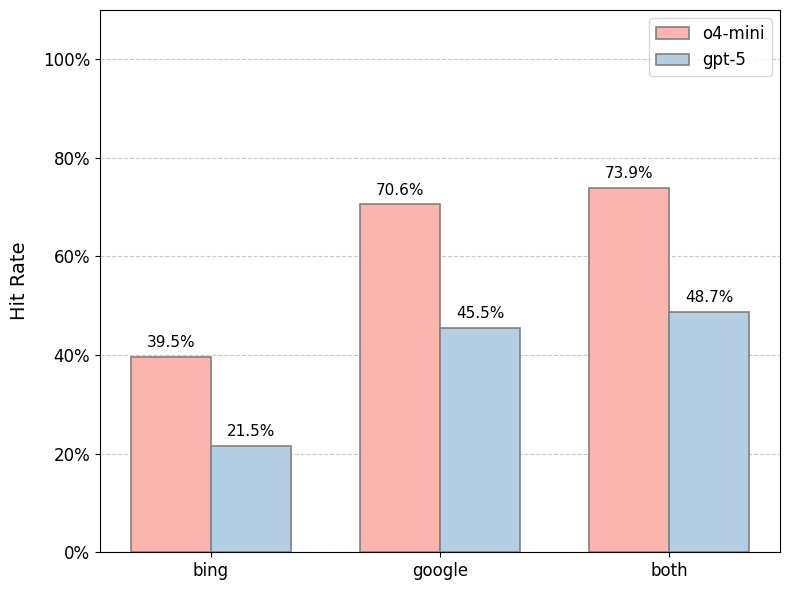

Overall rates (%):
       o4-mini   gpt-5
bing    39.52%  21.50%
google  70.55%  45.53%
both    73.89%  48.68%


In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# --- Helper: compute overall rates for one model family ---
def overall_rates(data, include_gpt5=False):
    totals = {'bing': 0, 'google': 0, 'both': 0, 'prompts': 0}
    for cat, recs in data.items():
        if include_gpt5 and "_gpt-5" not in cat:
            continue
        if not include_gpt5 and "_gpt-5" in cat:
            continue

        for rec in recs.values():
            p = set(rec['urls_from_prompt'])
            b = set(e['url'] for e in rec['bing_urls'])
            g = set(e['url'] for e in rec['google_urls'])
            totals['prompts'] += len(p)
            totals['bing']   += len(p & b)
            totals['google'] += len(p & g)
            totals['both']   += len(p & (b | g))

    denom = totals['prompts'] if totals['prompts'] else 1
    return {k: totals[k] / denom for k in ('bing', 'google', 'both')}

# --- Compute for both model families ---
rates_o4   = overall_rates(data, include_gpt5=False)  # o4-mini categories
rates_gpt5 = overall_rates(data, include_gpt5=True)   # gpt-5 categories

# --- Build a tidy DataFrame for plotting/printing ---
metrics = ['bing', 'google', 'both']
df = pd.DataFrame({
    'o4-mini':   [rates_o4[m]   for m in metrics],
    'gpt-5':     [rates_gpt5[m] for m in metrics],
}, index=metrics)

# --- Plot: grouped bars with same pastel/gray style ---
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(metrics))
bar_width = 0.35

cmap = plt.get_cmap('Pastel1')
bars_o4   = ax.bar(x - bar_width/2, df['o4-mini'].values, bar_width,
                   label='o4-mini', edgecolor='gray', linewidth=1.2,
                   color=cmap(0), zorder=3)
bars_gpt5 = ax.bar(x + bar_width/2, df['gpt-5'].values, bar_width,
                   label='gpt-5',   edgecolor='gray', linewidth=1.2,
                   color=cmap(1), zorder=3)

# y-axis formatting & grid
ax.set_ylim(0, 1.1)  # add headroom for labels
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# labels & title
ax.set_ylabel('Hit Rate', fontsize=14, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12)

# annotate bars with percentages
def annotate(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1%}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=11)

annotate(bars_o4)
annotate(bars_gpt5)

plt.tight_layout()
plt.show()

# --- Print numeric values (percent) ---
print('Overall rates (%):')
print(df.applymap(lambda v: f'{v:.2%}'))


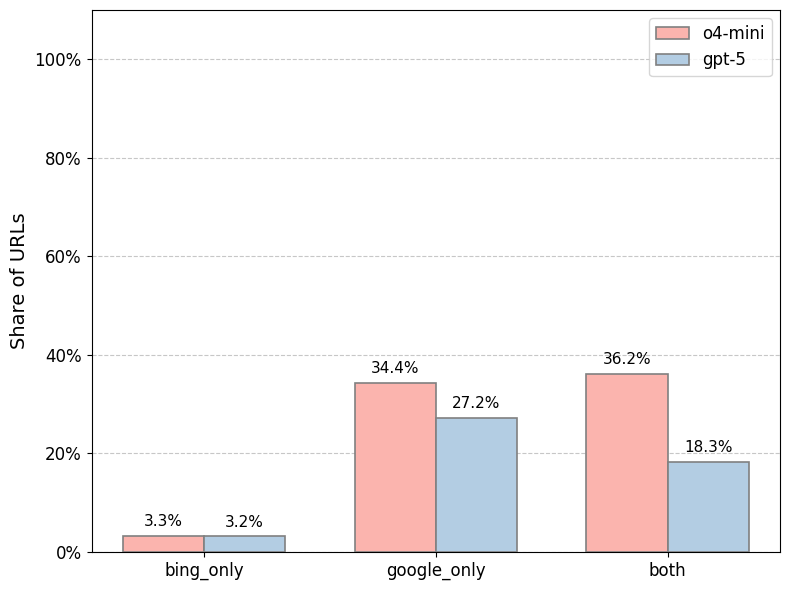

Coverage rates (%):
            o4-mini   gpt-5
bing_only     3.33%   3.16%
google_only  34.36%  27.18%
both         36.19%  18.34%

Sanity check counts (o4-mini): {'bing_only': 675, 'google_only': 6959, 'both': 7329, 'neither': 5288, 'prompts': 20251}
Sanity check counts (gpt-5): {'bing_only': 679, 'google_only': 5850, 'both': 3947, 'neither': 11044, 'prompts': 21520}


In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter
import copy

# --- Helper: compute coverage rates for one model family ---
def compute_coverage(data, include_gpt5=False):
    D = copy.deepcopy(data)
    totals = {'bing_only': 0, 'google_only': 0, 'both': 0, 'neither': 0, 'prompts': 0}

    for cat, recs in D.items():
        if include_gpt5 and "_gpt-5" not in cat:
            continue
        if not include_gpt5 and "_gpt-5" in cat:
            continue

        for rec in recs.values():
            p = set(rec.get('urls_from_prompt', []))
            b = set(e['url'] for e in rec.get('bing_urls', []))
            g = set(e['url'] for e in rec.get('google_urls', []))

            for u in p:
                totals['prompts'] += 1
                in_b, in_g = (u in b), (u in g)
                if in_b and in_g:
                    totals['both'] += 1
                elif in_b:
                    totals['bing_only'] += 1
                elif in_g:
                    totals['google_only'] += 1
                else:
                    totals['neither'] += 1

    denom = totals['prompts'] if totals['prompts'] else 1
    rates = {
        'bing_only':   totals['bing_only']   / denom,
        'google_only': totals['google_only'] / denom,
        'both':        totals['both']        / denom
    }
    return rates, totals

# --- Compute for o4-mini and gpt-5 ---
rates_o4, totals_o4   = compute_coverage(data, include_gpt5=False)
rates_gpt5, totals_g5 = compute_coverage(data, include_gpt5=True)

# --- DataFrame for plotting ---
labels = ['bing_only', 'google_only', 'both']
df = pd.DataFrame({
    'o4-mini': [rates_o4[l] for l in labels],
    'gpt-5':   [rates_gpt5[l] for l in labels]
}, index=labels)

# --- Plot grouped bars ---
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(labels))
bar_width = 0.35
cmap = plt.get_cmap('Pastel1')

bars_o4 = ax.bar(x - bar_width/2, df['o4-mini'].values, bar_width,
                 label='o4-mini', edgecolor='gray', linewidth=1.2,
                 color=cmap(0), zorder=3)
bars_g5 = ax.bar(x + bar_width/2, df['gpt-5'].values, bar_width,
                 label='gpt-5', edgecolor='gray', linewidth=1.2,
                 color=cmap(1), zorder=3)

# y-axis & grid
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# labels & title
ax.set_ylabel('Share of URLs', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12)

# annotate percentages
def annotate(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1%}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=11)

annotate(bars_o4)
annotate(bars_g5)

plt.tight_layout()
plt.show()

# --- Print numeric results ---
print("Coverage rates (%):")
print(df.applymap(lambda v: f"{v:.2%}"))
print("\nSanity check counts (o4-mini):", totals_o4)
print("Sanity check counts (gpt-5):", totals_g5)


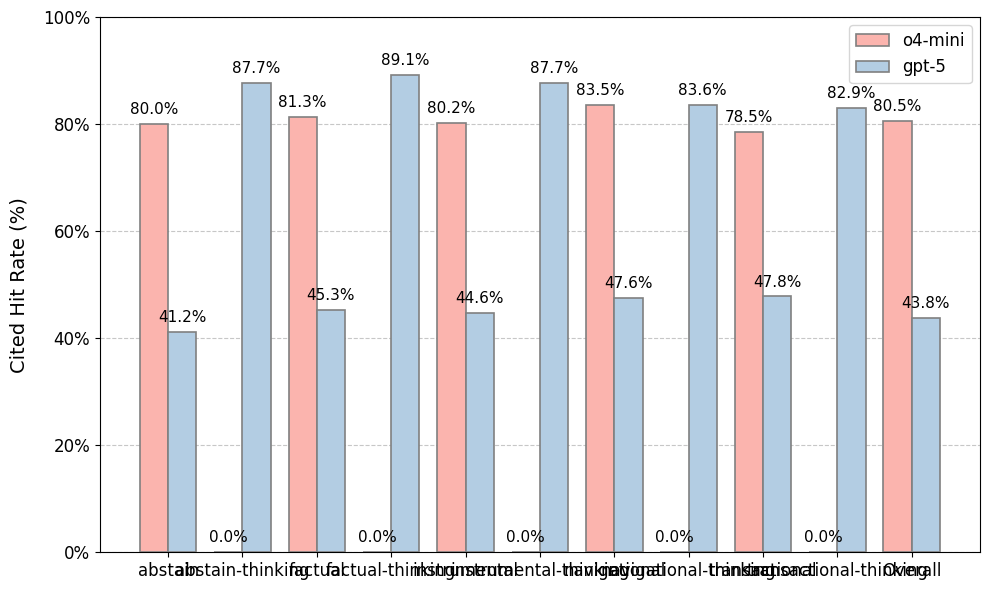

Overall cited hit rate (o4-mini): 80.49%
Overall cited hit rate (gpt-5):   43.81%


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter
import copy

# --- Helper to compute per-category cited hit rates for one model family ---
def cited_rates_by_category(data, include_gpt5=False):
    D = copy.deepcopy(data)
    records = []
    overall = {'hits': 0, 'total': 0}

    for cat, har_dict in D.items():
        if include_gpt5 and "_gpt-5" not in cat:
            continue
        if not include_gpt5 and "_gpt-5" in cat:
            continue

        for rec in har_dict.values():
            cited = {strip_utm(u) for u in rec.get('urls_cited', [])}
            found = {strip_utm(e['url']) for e in rec.get('bing_urls', []) + rec.get('google_urls', [])}
            total_c = len(cited)
            if total_c == 0:
                continue
            hits_c = len(cited & found)
            overall['hits']  += hits_c
            overall['total'] += total_c
            records.append({'category': cat.replace('_gpt-5', ''), 'rate_cited': hits_c / total_c})

    if not records:
        # Return empty series and overall=0 if nothing found
        return pd.Series(dtype=float), 0.0

    df = pd.DataFrame(records)
    avg_by_cat = df.groupby('category')['rate_cited'].mean().sort_index()
    overall_rate = (overall['hits'] / overall['total']) if overall['total'] else 0.0
    # Append Overall
    avg_with_overall = pd.concat([avg_by_cat, pd.Series({'Overall': overall_rate})])
    return avg_with_overall, overall_rate

# --- Compute for both model families ---
avg_o4, overall_o4     = cited_rates_by_category(data, include_gpt5=False)
avg_gpt5, overall_gpt5 = cited_rates_by_category(data, include_gpt5=True)

# --- Align categories (including Overall) ---
all_idx = sorted(set(avg_o4.index) | set(avg_gpt5.index), key=lambda x: ('zzz' if x=='Overall' else x.lower()))
avg_o4   = avg_o4.reindex(all_idx, fill_value=0.0)
avg_gpt5 = avg_gpt5.reindex(all_idx, fill_value=0.0)

# --- Plot grouped bars with your pastel style ---
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(all_idx))
bar_width = 0.38
cmap = plt.get_cmap('Pastel1')

bars_o4 = ax.bar(x - bar_width/2, (avg_o4.values * 100), bar_width,
                 label='o4-mini', edgecolor='gray', linewidth=1.2,
                 color=cmap(0), zorder=3)
bars_g5 = ax.bar(x + bar_width/2, (avg_gpt5.values * 100), bar_width,
                 label='gpt-5', edgecolor='gray', linewidth=1.2,
                 color=cmap(1), zorder=3)

# Axis formatting
ax.set_ylim(0, 100)  # percentage scale (0–100)
ax.yaxis.set_major_formatter(PercentFormatter(100.0))
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)

# Titles & labels
ax.set_ylabel('Cited Hit Rate (%)', fontsize=14, labelpad=10)
ax.set_xticks(x)
labels = ["instrumental" if lbl == "instramental" else lbl for lbl in all_idx]
ax.set_xticklabels(labels, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=12)

# Annotations (%)
def annotate(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom', fontsize=11)

annotate(bars_o4)
annotate(bars_g5)

plt.tight_layout()
plt.show()

# Print numeric overall rates
print('Overall cited hit rate (o4-mini):', f'{overall_o4:.2%}')
print('Overall cited hit rate (gpt-5):  ', f'{overall_gpt5:.2%}')


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= Load & prepare (both models) =========
# o4-mini
df_o4 = pd.read_csv("o4-mini-categories-stats.csv")
df_o4 = df_o4[~df_o4['category'].astype(str).str.contains("_gpt-5", na=False)].copy()
df_o4['category'] = df_o4['category'].astype(str)
df_o4['total_time_sec'] = df_o4['total_time_ms'] / 1000.0

# gpt-5
df_g5 = pd.read_csv("gpt-5-categories-stats.csv")
# If categories in this file have the suffix, strip it so categories align:
df_g5['category'] = df_g5['category'].astype(str).str.replace("_gpt-5", "", regex=False)
df_g5['total_time_sec'] = df_g5['total_time_ms'] / 1000.0

# ========= Overall summaries (print only) =========
def print_overall_summary(label, df):
    average_time = df['total_time_sec'].mean()
    average_transfer_size = df['transfer_size'].mean()
    average_accessed = df['n_accessed'].mean()
    average_given = df['n_given'].mean()

    min_time = df['total_time_sec'].min(); max_time = df['total_time_sec'].max()
    min_transfer_size = df['transfer_size'].min(); max_transfer_size = df['transfer_size'].max()
    min_accessed = df['n_accessed'].min(); max_accessed = df['n_accessed'].max()
    min_given = df['n_given'].min(); max_given = df['n_given'].max()

    print(f"[{label}] Average time: {average_time:.2f}s (min: {min_time:.2f}s, max: {max_time:.2f}s)")
    print(f"[{label}] Average transfer size: {average_transfer_size:.2f} B (min: {min_transfer_size}B, max: {max_transfer_size}B)")
    print(f"[{label}] Average URLs accessed: {average_accessed:.2f} (min: {min_accessed}, max: {max_accessed})")
    print(f"[{label}] Average URLs given: {average_given:.2f} (min: {min_given}, max: {max_given})")

print_overall_summary("o4-mini", df_o4)
print_overall_summary("gpt-5", df_g5)

# ========= Per-category means (each model) =========
grp_o4 = df_o4.groupby('category', sort=True)
grp_g5 = df_g5.groupby('category', sort=True)

avg_time_o4 = grp_o4['total_time_sec'].mean().sort_index()
avg_time_g5 = grp_g5['total_time_sec'].mean().sort_index()

avg_xfer_o4 = grp_o4['transfer_size'].mean().sort_index()
avg_xfer_g5 = grp_g5['transfer_size'].mean().sort_index()

avg_acc_o4  = grp_o4['n_accessed'].mean().sort_index()
avg_acc_g5  = grp_g5['n_accessed'].mean().sort_index()

avg_giv_o4  = grp_o4['n_given'].mean().sort_index()
avg_giv_g5  = grp_g5['n_given'].mean().sort_index()

# ========= Helpers: pastel grouped bars (o4 vs gpt-5) =========
def fix_labels(ax):
    current_labels = [t.get_text() for t in ax.get_xticklabels()]
    fixed_labels = ["instrumental" if lbl == "instramental" else lbl for lbl in current_labels]
    ax.set_xticklabels(fixed_labels)

def grouped_bar_models(series_o4, series_g5, title, ylabel, value_fmt="{:.2f}"):
    # Align categories
    cats = sorted(set(series_o4.index) | set(series_g5.index))
    s_o4 = series_o4.reindex(cats, fill_value=0)
    s_g5 = series_g5.reindex(cats, fill_value=0)

    x = np.arange(len(cats))
    bar_width = 0.38

    cmap = plt.get_cmap('Pastel1')
    color_o4, color_g5 = cmap(0), cmap(1)

    fig, ax = plt.subplots(figsize=(12, 6))
    bars_o4 = ax.bar(
        x - bar_width/2, s_o4.values, width=bar_width, label='o4-mini',
        edgecolor='gray', linewidth=1.2, color=color_o4, zorder=3
    )
    bars_g5 = ax.bar(
        x + bar_width/2, s_g5.values, width=bar_width, label='gpt-5',
        edgecolor='gray', linewidth=1.2, color=color_g5, zorder=3
    )

    ymax = max(s_o4.max(), s_g5.max())
    ax.set_ylim(0, ymax * 1.25 if ymax > 0 else 1.0)
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=0, fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax.legend(fontsize=12)

    # annotations
    def annotate(bars):
        for bar in bars:
            h = bar.get_height()
            ax.annotate(
                value_fmt.format(h),
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=11
            )
    annotate(bars_o4); annotate(bars_g5)

    fix_labels(ax)
    plt.tight_layout()
    plt.show()

# ========= Charts (o4-mini vs gpt-5) =========

# 1) Average total time (seconds) per category
grouped_bar_models(
    avg_time_o4, avg_time_g5,
    title="",
    ylabel="Time (seconds)",
    value_fmt="{:.2f}"
)

# 2) Average transfer size (bytes) per category
grouped_bar_models(
    avg_xfer_o4, avg_xfer_g5,
    title="",
    ylabel="Bytes",
    value_fmt="{:.0f}"
)

# 3) Average URLs Accessed per category (o4 vs gpt-5)
grouped_bar_models(
    avg_acc_o4, avg_acc_g5,
    title="",
    ylabel="URLs Accessed Count",
    value_fmt="{:.2f}"
)

# 4) Average URLs Given per category (o4 vs gpt-5)
grouped_bar_models(
    avg_giv_o4, avg_giv_g5,
    title="",
    ylabel="URLs Cited Count",
    value_fmt="{:.2f}"
)


FileNotFoundError: [Errno 2] No such file or directory: 'o4-mini-categories-stats.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.cm import get_cmap

# ========= Load both datasets =========
df_o4 = pd.read_csv("o4-mini-categories-stats.csv").copy()
df_o4 = df_o4[~df_o4['category'].astype(str).str.contains("_gpt-5", na=False)]
df_o4['category'] = df_o4['category'].astype(str)

df_g5 = pd.read_csv("gpt-5-categories-stats.csv").copy()
df_g5['category'] = df_g5['category'].astype(str).str.replace("_gpt-5", "", regex=False)

# ========= Build ordered category list (union, sorted) =========
cats = sorted(set(df_o4['category'].unique()) | set(df_g5['category'].unique()))

# Helper: get per-category value arrays (dropna)
def per_cat_lists(df, col, cats):
    return [df.loc[df['category'] == c, col].dropna().values for c in cats]

acc_lists_o4 = per_cat_lists(df_o4, 'n_accessed', cats)
acc_lists_g5 = per_cat_lists(df_g5, 'n_accessed', cats)
giv_lists_o4 = per_cat_lists(df_o4, 'n_given',    cats)
giv_lists_g5 = per_cat_lists(df_g5, 'n_given',    cats)

# ========= Shared plotter: paired boxplots per category =========
def paired_pastel_boxplot(ax, data_lists_A, data_lists_B, cats, title, ylabel,
                          label_A='o4-mini', label_B='gpt-5'):
    """
    Draw side-by-side boxplots per category:
      left = model A (o4-mini), right = model B (gpt-5)
    Keeps pastel fills, gray edges, dashed y-grid, and mean/median legend.
    """
    n = len(cats)
    x = np.arange(n)

    # positions with a small gap between A and B
    width = 0.35
    gap = 0.06
    pos_A = x - (width/2 + gap/2)
    pos_B = x + (width/2 + gap/2)

    cmap = get_cmap('Pastel1')
    color_A = cmap(0)  # o4-mini
    color_B = cmap(1)  # gpt-5

    # A (o4-mini)
    bpA = ax.boxplot(
        data_lists_A, positions=pos_A, widths=width,
        patch_artist=True, showmeans=True, meanline=True, whis=1.5
    )
    # B (gpt-5)
    bpB = ax.boxplot(
        data_lists_B, positions=pos_B, widths=width,
        patch_artist=True, showmeans=True, meanline=True, whis=1.5
    )

    # Style function
    def style_bp(bp, facecolor):
        for patch in bp['boxes']:
            patch.set_facecolor(facecolor)
            patch.set_edgecolor('gray')
            patch.set_linewidth(1.2)
        for key in ('whiskers', 'caps', 'means', 'medians'):
            for artist in bp[key]:
                if key == 'medians':
                    artist.set_color('black')
                else:
                    artist.set_color('gray')
                artist.set_linewidth(1.2)

    style_bp(bpA, color_A)
    style_bp(bpB, color_B)

    # Axes, grid, labels
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_ylabel(ylabel, fontsize=14, labelpad=10)
    ax.tick_params(axis='y', labelsize=12)

    # X ticks centered between the two positions
    ax.set_xticks(x)
    # DISPLAY-ONLY LABEL FIX
    fixed_cats = ["instrumental" if lbl == "instramental" else lbl for lbl in cats]
    ax.set_xticklabels(fixed_cats, rotation=0, fontsize=12)

    # Legend (median & mean + model labels)
    median_ln = mlines.Line2D([], [], color='black', linewidth=1.5, label='Median')
    mean_ln   = mlines.Line2D([], [], color='gray',  linewidth=1.5, label='Mean', linestyle='-')
    modelA_ln = mlines.Line2D([], [], color=color_A, linewidth=10, label=label_A)
    modelB_ln = mlines.Line2D([], [], color=color_B, linewidth=10, label=label_B)
    ax.legend(handles=[median_ln, mean_ln, modelA_ln, modelB_ln], fontsize=11, loc='upper right')

# ========= Plot: URLs Accessed =========
fig, ax = plt.subplots(figsize=(14, 6))
paired_pastel_boxplot(
    ax, acc_lists_o4, acc_lists_g5, cats,
    title="",
    ylabel="URLs Accessed",
    label_A="o4-mini", label_B="gpt-5"
)
plt.tight_layout()
plt.show()

# ========= Plot: URLs Cited =========
fig, ax = plt.subplots(figsize=(14, 6))
paired_pastel_boxplot(
    ax, giv_lists_o4, giv_lists_g5, cats,
    title="",
    ylabel="URLs Cited",
    label_A="o4-mini", label_B="gpt-5"
)
plt.tight_layout()
plt.show()




FileNotFoundError: [Errno 2] No such file or directory: 'o4-mini-categories-stats.csv'

In [ ]:
for i in data['abstain']:
    if len(data['abstain'][i]['urls_from_prompt']) > 50:
        print(i)

KeyError: 'network-logs-prompt-359_20250814_013030'